# Notebook 03 — Text Preprocessing & Feature Engineering

**Purpose:** Apply the full preprocessing pipeline to the cleaned dataset and produce the TF-IDF feature matrix.

**Steps applied:**
1. Lowercase
2. Nigerian Pidgin Normalisation
3. Punctuation removal (digits retained)
4. Stop word removal
5. TF-IDF Vectorisation (unigrams + bigrams, max 5,000 features)

**Output:** `data/processed/preprocessed_dataset.csv` + vocabulary inspection

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

sys.path.append(os.path.abspath('..'))
from src.preprocessor import preprocess, preprocess_batch
from src.pidgin_dict import PIDGIN_DICT

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 12,
    'figure.dpi': 150,
})

PROCESSED_DIR = '../data/processed/'
FIGURES_DIR   = '../outputs/figures/'
MODELS_DIR    = '../models/'

os.makedirs(MODELS_DIR, exist_ok=True)
print('Libraries and src modules loaded.')

Libraries and src modules loaded.


In [3]:
# ── Load cleaned dataset ──────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/cleaned_dataset.csv')
print(f'Dataset loaded: {len(df)} messages')
df.head(3)

Dataset loaded: 3903 messages


,label,label_str,message,sender,direction,timestamp
0,1,SPAM,CANCLE,127,send,04/09/2014 08:29
1,1,SPAM,Your plan Smallie.is going to be renewed. Plea...,127,receive,04/09/2014 08:25
2,1,SPAM,"Dear Glo subscriber, you just passed 80% of yo...",127,receive,04/09/2014 08:25


In [9]:
# ── Demonstrate Pidgin normalisation ─────────────────────────────────────────
# Show before and after on sample messages
from src.preprocessor import to_lowercase, normalise_pidgin, remove_punctuation, remove_stopwords

samples = [
    "Your admission don show, abeg call sharp sharp",
    "e dey expire today, no waste time send money",
    "Make you no do runz, sorting don start for the centre",
    "Abeg confirm ur JAMB result now now before e go expire",
]

print('Nigerian Pidgin Normalisation — Before vs After:')
print('=' * 70)
for s in samples:
    normalised = normalise_pidgin(to_lowercase(s))
    print(f'  BEFORE : {s}')
    print(f'  AFTER  : {normalised}')
    print('-' * 70)

Nigerian Pidgin Normalisation — Before vs After:
  BEFORE : Your admission don show, abeg call sharp sharp
  AFTER  : your admission has show, please call immediately
----------------------------------------------------------------------
  BEFORE : e dey expire today, no waste time send money
  AFTER  : it is expiring today, do not waste time send money
----------------------------------------------------------------------
  BEFORE : Make you no do runz, sorting don start for the centre
  AFTER  : ensure you do not do exam fraud, bribery don start for the centre
----------------------------------------------------------------------
  BEFORE : Abeg confirm ur JAMB result now now before e go expire
  AFTER  : please confirm your jamb result right now before it will expire
----------------------------------------------------------------------


In [10]:
# ── Apply full preprocessing pipeline ────────────────────────────────────────
print('Applying preprocessing pipeline...')
df['cleaned_message'] = preprocess_batch(df['message'])

# Drop rows where preprocessing produced empty strings
before = len(df)
df = df[df['cleaned_message'].str.strip() != ''].reset_index(drop=True)
after = len(df)
print(f'Rows dropped after preprocessing (empty result): {before - after}')
print(f'Final dataset size: {after} messages')

Applying preprocessing pipeline...
Rows dropped after preprocessing (empty result): 0
Final dataset size: 3886 messages


In [11]:
# ── Before vs After preprocessing — sample comparison ────────────────────────
print('Sample messages — Before and After Full Pipeline:')
print('=' * 70)
for i in range(5):
    row = df.iloc[i]
    print(f'  [{row["label_str"]}]')
    print(f'  BEFORE : {row["message"][:120]}')
    print(f'  AFTER  : {row["cleaned_message"][:120]}')
    print('-' * 70)

Sample messages — Before and After Full Pipeline:
  [SPAM]
  BEFORE : CANCLE
  AFTER  : cancle
----------------------------------------------------------------------
  [SPAM]
  BEFORE : Your plan Smallie.is going to be renewed. Please send CANCEL if you do not want this to happen
  AFTER  : your plan smallie going renewed please send cancel you not want happen
----------------------------------------------------------------------
  [SPAM]
  BEFORE : Dear Glo subscriber, you just passed 80% of your Plan Validity Period. Glo Unlimited.
  AFTER  : dear glo subscriber you passed 80 your plan validity period glo unlimited
----------------------------------------------------------------------
  [SPAM]
  BEFORE : Welcome to Smallie. It will expire on 04/09/2014 14:19
  AFTER  : welcome smallie will expire 04 09 2014 14 19
----------------------------------------------------------------------
  [SPAM]
  BEFORE : Info
  AFTER  : info
-------------------------------------------------------------

In [12]:
# ── TF-IDF Vectorisation ──────────────────────────────────────────────────────
# Fit on the FULL dataset here for vocabulary inspection only.
# In Notebook 04, vectoriser is fitted on training set only (correct ML practice).

vectoriser_inspect = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_inspect = vectoriser_inspect.fit_transform(df['cleaned_message'])

vocab = vectoriser_inspect.get_feature_names_out()
print(f'Vocabulary size     : {len(vocab)} features')
print(f'Feature matrix shape: {X_inspect.shape}')
print(f'Matrix density      : {X_inspect.nnz / (X_inspect.shape[0] * X_inspect.shape[1]):.4f} (sparse)')
print(f'\nSample unigrams : {[v for v in vocab if " " not in v][:20]}')
print(f'Sample bigrams  : {[v for v in vocab if " " in v][:20]}')

Vocabulary size     : 5000 features
Feature matrix shape: (3886, 5000)
Matrix density      : 0.0032 (sparse)

Sample unigrams : ['00', '000', '001', '001dt', '00am', '00bal', '00br', '00from', '00mb', '00ngn', '00pm', '00prev', '00xxxxxx36', '01', '0130567609', '01xxxxxx09', '01xxxxxx42', '02', '03', '032130']
Sample bigrams  : ['00 01', '00 03', '00 04', '00 05', '00 06', '00 12', '00 13', '00 14', '00 16', '00 17', '00 21', '00 23', '00 25', '00 26', '00 28', '00 ammc', '00 bal', '00 bonus', '00 crdesc', '00 drdesc']


In [13]:
# ── Top TF-IDF terms by class ─────────────────────────────────────────────────
import numpy as np

tfidf_df = pd.DataFrame(
    X_inspect.toarray(),
    columns=vocab
)
tfidf_df['label'] = df['label'].values

spam_tfidf = tfidf_df[tfidf_df['label']==1].drop('label', axis=1).mean().sort_values(ascending=False)
ham_tfidf  = tfidf_df[tfidf_df['label']==0].drop('label', axis=1).mean().sort_values(ascending=False)

print('Top 15 TF-IDF terms — SPAM messages:')
print(spam_tfidf.head(15).to_string())
print()
print('Top 15 TF-IDF terms — HAM messages:')
print(ham_tfidf.head(15).to_string())

Top 15 TF-IDF terms — SPAM messages:
you        0.039622
your       0.037348
text       0.030606
free       0.025755
get        0.024365
n50        0.016106
data       0.015981
dial       0.015559
sms        0.014322
now        0.014239
will       0.013695
service    0.013422
mtn        0.013225
n100       0.012130
send       0.012044

Top 15 TF-IDF terms — HAM messages:
your      0.025771
please    0.024869
you       0.022738
no        0.016288
sir       0.015497
call      0.015136
thanks    0.014448
now       0.014242
ma        0.013824
acct      0.012838
god       0.012552
dear      0.012195
not       0.012192
00        0.012018
bal       0.011465


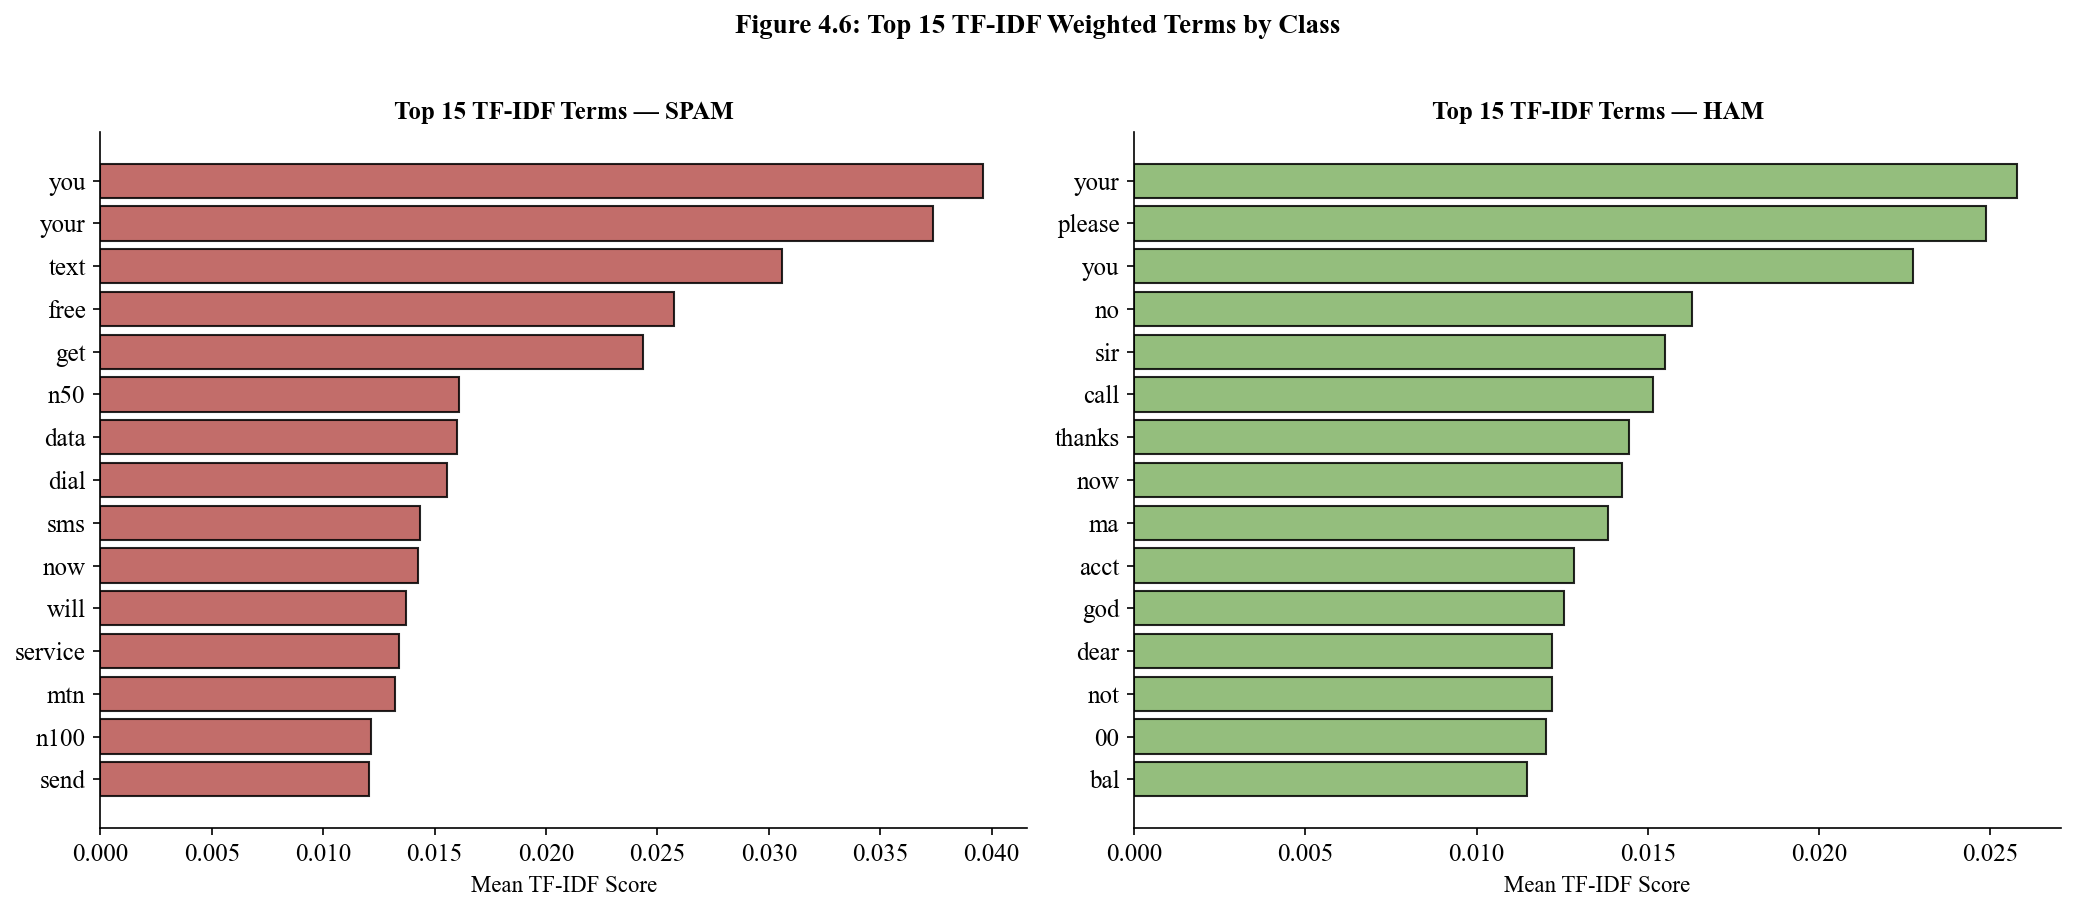

Saved: fig4_6_tfidf_terms.png


In [14]:
# ── Plot: Top 15 TF-IDF terms by class ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_n = 15

axes[0].barh(
    spam_tfidf.head(top_n).index[::-1],
    spam_tfidf.head(top_n).values[::-1],
    color='#b85450', edgecolor='black', alpha=0.85
)
axes[0].set_title('Top 15 TF-IDF Terms — SPAM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF Score', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].barh(
    ham_tfidf.head(top_n).index[::-1],
    ham_tfidf.head(top_n).values[::-1],
    color='#82b366', edgecolor='black', alpha=0.85
)
axes[1].set_title('Top 15 TF-IDF Terms — HAM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean TF-IDF Score', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Figure 4.6: Top 15 TF-IDF Weighted Terms by Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_6_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_6_tfidf_terms.png')

In [15]:
# ── Save preprocessed dataset ─────────────────────────────────────────────────
out_path = os.path.join(PROCESSED_DIR, 'preprocessed_dataset.csv')
df[['label', 'label_str', 'message', 'cleaned_message']].to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {df.shape}')
print()
print('=' * 50)
print('PREPROCESSING COMPLETE')
print('=' * 50)
print(f'  Input messages  : {len(df)}')
print(f'  Vocabulary size : {len(vocab)} features')
print(f'  n-gram range    : (1, 2) — unigrams and bigrams')
print(f'  Matrix shape    : {X_inspect.shape}')

Saved: ../data/processed/preprocessed_dataset.csv
Shape: (3886, 7)

PREPROCESSING COMPLETE
  Input messages  : 3886
  Vocabulary size : 5000 features
  n-gram range    : (1, 2) — unigrams and bigrams
  Matrix shape    : (3886, 5000)
